> 📅 __Date: 2026-08-11__

# **Positional Encoding**

In natural language, **the order of tokens is important**.

**Consider:**

```text
"Dog chased cat."
```

**and:**

```text
"Cat chased dog."
```

Both sentences contain the same words, but their meanings are different because the **positions of the words are different**.

The Transformer uses **Self-Attention**, which can process tokens in parallel, but Self-Attention by itself does not provide information about token order.

**Therefore:**

> **Positional Encoding is used to provide position information to the Transformer.**

---

# 🎯 **Why Do We Need Positional Encoding?**

**Suppose the sentence is:**

```text
"We are learning transformer"
```

**After tokenization:**

```text
["We", "are", "learning", "transformer"]
```

**The tokens have positions:**

```text
"We"          → Position 1

"are"         → Position 2

"learning"    → Position 3

"transformer" → Position 4
```

**The Transformer needs to know:**

```text
Which token comes first?

Which token comes second?

Which token comes third?

Which token comes fourth?
```

Without positional information, the model would not directly know the order in which the tokens appeared.

**Therefore:**

```text
Token Embedding
       +
Positional Encoding
       ↓
Position-Aware Representation
```

---

# 📍 **What is Positional Encoding?**

Positional Encoding is a vector that represents the **position of a token** in a sequence.

**The basic idea is:**

```text
Each position
      ↓
gets a positional vector
      ↓
that vector is added to the token embedding
```

**For example:**

```text
Position 1 → P₁

Position 2 → P₂

Position 3 → P₃

Position 4 → P₄
```

**Suppose:**

```text
"We" → W
"are" → A
"learning" → L
"transformer" → T
```

**Then:**

```text
W + P₁

A + P₂

L + P₃

T + P₄
```

**So the final representation contains both:**

```text
Meaning of token
       +
Position of token
```

---

# 🧠 **Main Idea**

The Transformer does not replace the token embedding with the positional encoding.

**Instead:**

> **The positional encoding is added to the token embedding.**

**Therefore:**

```text
Token Embedding
       +
Positional Encoding
       ↓
Input to Transformer
```

---

# 📌 **Properties of Positional Encoding**

A useful positional encoding should have important properties.

## **1. Different positions should have distinguishable encodings**

**For example:**

```text
P₁ ≠ P₂

P₂ ≠ P₃

P₃ ≠ P₄
```

The model should be able to distinguish one position from another.

---

## **2. Dimension must match the embedding dimension**

**Suppose:**

```text
Embedding Dimension = 512
```

**Then:**

```text
Positional Encoding Dimension = 512
```

**Therefore:**

```text
Dimension(Token Embedding)
=
Dimension(Positional Encoding)
=
d_model
```

This is necessary because the two vectors are added element-wise.

**For example:**

```text
Token Embedding:

[ e₁, e₂, e₃, ..., e₅₁₂ ]

Positional Encoding:

[ p₁, p₂, p₃, ..., p₅₁₂ ]

                 ↓

Element-wise addition

                 ↓

[ e₁+p₁, e₂+p₂, e₃+p₃, ..., e₅₁₂+p₅₁₂ ]
```

---

## **3. Positional information should not destroy token information**

**The goal is to combine:**

```text
Semantic Information
+
Position Information
```

rather than completely overwrite the token representation.

A useful practical detail from the original Transformer is that the token embeddings are scaled by:

```text
√d_model
```

before positional encoding is added.

**So, conceptually:**

```text
Scaled Token Embedding
        +
Positional Encoding
        ↓
Transformer Input
```

This is more precise than saying that positional encoding must simply have "small values."

---

# 🧩 **Methods of Positional Encoding**

**There are two common approaches:**

```text
1. Learned Positional Encoding

2. Sinusoidal Positional Encoding
```

---

# 🟡 **1. Learned Positional Encoding**

In Learned Positional Encoding, the positional vectors are treated as **learnable parameters**.

**Suppose the maximum sequence length is:**

```text
500
```

**and:**

```text
d_model = 512
```

**Then the model can learn a positional embedding matrix of approximately:**

```text
500 × 512
```

**Each row represents one position:**

```text
P₁ → 512-dimensional vector

P₂ → 512-dimensional vector

P₃ → 512-dimensional vector

...

P₅₀₀ → 512-dimensional vector
```

These vectors are learned during training.

---

# ⚠️ **Limitations of Learned Positional Encoding**

## **1. Usually tied to a chosen maximum length**

**If positional embeddings are learned only for:**

```text
P₁, P₂, ..., P₅₀₀
```

**then the model does not automatically have a learned vector for:**

```text
P₅₀₁
P₅₀₂
...
```

Therefore, handling sequences longer than the trained positional range requires an additional mechanism, such as extending or replacing the positional representation.

---

## **2. Additional parameters**

The positional embeddings introduce trainable parameters.

**For:**

```text
Maximum Length = L

Embedding Dimension = d_model
```

**the positional embedding table contains:**

```text
L × d_model
```

trainable values.

This is usually not a huge computational cost, but it increases the number of model parameters.

---

# 🔵 **2. Sinusoidal Positional Encoding**

**The original Transformer paper used:**

> **Sinusoidal Positional Encoding**

**It uses two mathematical functions:**

```text
sin()
cos()
```

Instead of learning each positional vector, the vector is **deterministically calculated** from the position.

**For example:**

```text
P₁

P₂

P₃

P₄

...

P₅₀₀
```

Each position receives a different pattern of sine and cosine values.

---

# 🌊 **Why Sin and Cos?**

Sine and cosine functions are periodic and produce smooth, structured patterns.

**For example:**

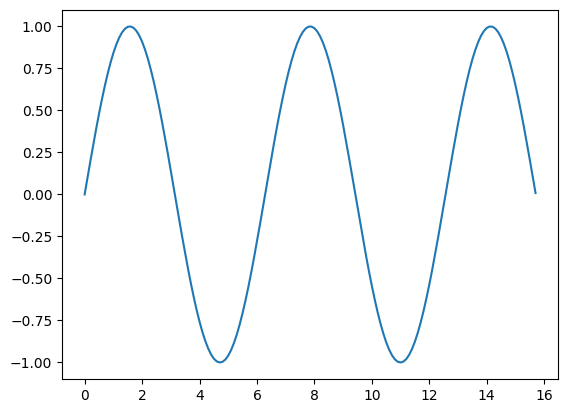

In [1]:
import numpy as np
import matplotlib.pyplot as plt

arr = np.arange(0, 5*np.pi, 0.1)

y = np.sin(arr)

plt.plot(arr, y)
plt.show()

The values continuously change with position.

**We can also look at a longer range:**

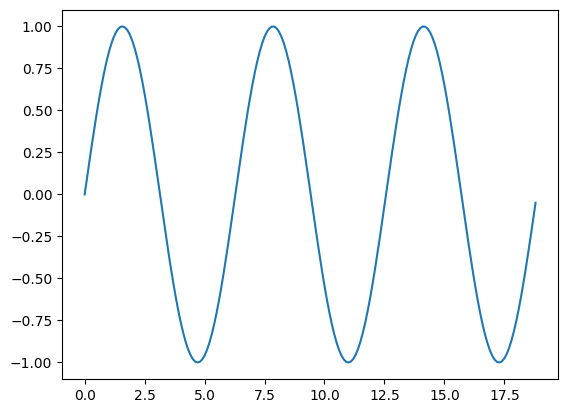

In [2]:
arr = np.arange(0, 6*np.pi, 0.1)

y = np.sin(arr)

plt.plot(arr, y)
plt.show()

The Transformer uses many sine and cosine functions with different frequencies so that different dimensions carry positional information at different scales.

---

# 📐 **Dimension of Positional Encoding**

The positional encoding has the same dimension as the model representation.

**In the original Transformer:**

```text
d_model = 512
```

**Therefore:**

```text
Dimension of Token Embedding
=
512
```

**and:**

```text
Dimension of Positional Encoding
=
512
```

So every position is represented by a 512-dimensional vector.

**For example:**

```text
P₁ = [p₁, p₂, p₃, ..., p₅₁₂]

P₂ = [p₁, p₂, p₃, ..., p₅₁₂]

P₃ = [p₁, p₂, p₃, ..., p₅₁₂]
```

The values are different for each position.

---

# 🖼️ **Visual Representation**

<div align="center">

<img src="assets/pos_encoding.png" width="700" alt="Positional Encoding">

<p><em>Figure: Positional Encoding added to token embeddings.</em></p>

</div>

---

# 🧮 **Sinusoidal Positional Encoding Formula**

The original Transformer defines the positional encoding as:

$$
PE_{(pos,2i)}
=
\sin
\left(
\frac{pos}
{10000^{\frac{2i}{d_{model}}}}
\right)
$$

$$
PE_{(pos,2i+1)}
=
\cos
\left(
\frac{pos}
{10000^{\frac{2i}{d_{model}}}}
\right)
$$

**where:**

```text
pos     = position of the token

i       = dimension index used in the formula

d_model = model / embedding dimension
```

In the original Transformer:

```text
d_model = 512
```

---

# 🖼️ **Sinusoidal Formula Visualization**

<div align="center">

<img src="assets/Pos_enc_for.png" width="700" alt="Sinusoidal Positional Encoding Formula">

<p><em>Figure: Sinusoidal positional encoding formula.</em></p>

</div>

---

# 🔢 **How are Dimensions Assigned?**

**The dimensions alternate between:**

```text
Even dimensions → sin

Odd dimensions  → cos
```

**For example:**

```text
Dimension 0 → sin

Dimension 1 → cos

Dimension 2 → sin

Dimension 3 → cos

Dimension 4 → sin

Dimension 5 → cos

...

Dimension 510 → sin

Dimension 511 → cos
```

**Therefore:**

```text
Even index → sin()

Odd index  → cos()
```

---

# 🔍 **Understanding the Formula**

**Consider:**

$$
PE_{(pos,2i)}
=
\sin
\left(
\frac{pos}
{10000^{\frac{2i}{d_{model}}}}
\right)
$$

**For the cosine dimensions:**

$$
PE_{(pos,2i+1)}
=
\cos
\left(
\frac{pos}
{10000^{\frac{2i}{d_{model}}}}
\right)
$$

**There are three important variables:**

```text
pos

i

d_model
```

---

# 📌 **What is `pos`?**

`pos` represents the position of the token.

**For example:**

```text
"We"          → pos = 1

"are"         → pos = 2

"learning"    → pos = 3

"transformer" → pos = 4
```

---

# 📌 **What is `i`?**

`i` identifies the pair of dimensions used by the formula.

**For example:**

```text
i = 0
i = 1
i = 2
i = 3
...
```

**The corresponding dimensions are:**

```text
2i

2i+1
```

**So when:**

```text
i = 0
```

**we use dimensions:**

```text
0
1
```

**When:**

```text
i = 1
```

**we use dimensions:**

```text
2
3
```

**When:**

```text
i = 2
```

**we use dimensions:**

```text
4
5
```

and so on.

---

# 📌 **What is `d_model`?**

`d_model` is the dimension of the Transformer representation.

**In the original Transformer:**

```text
d_model = 512
```

**Therefore:**

```text
Embedding Dimension = 512

Positional Encoding Dimension = 512
```

---

# 🧮 **Calculate the First Positional Encoding Value**

**Let's calculate the first value for:**

```text
pos = 1

i = 0

d_model = 512
```

**Since this is an even dimension:**

$$
PE_{(1,0)}
=
\sin
\left(
\frac{1}
{10000^{\frac{2(0)}{512}}}
\right)
$$

**First calculate:**

$$
\frac{2(0)}{512}=0
$$

**Therefore:**

$$
PE_{(1,0)}
=
\sin
\left(
\frac{1}
{10000^0}
\right)
$$

**Since:**

$$
10000^0=1
$$

**we get:**

$$
PE_{(1,0)}
=
\sin(1)
$$

**Therefore:**

```python
import numpy as np

np.sin(1)
```

**Output:**

```text
0.84147098
```

**So:**

```text
PE(1, 0) ≈ 0.84
```

This is the value of the **first dimension of the positional vector for position 1**.

---

# 🧠 **Building P₁**

**For:**

```text
Position = 1
```

**the positional encoding vector is:**

```text
P₁ = [
    PE(1,0),
    PE(1,1),
    PE(1,2),
    PE(1,3),
    ...
    PE(1,511)
]
```

**Therefore:**

```text
P₁ = [
    sin(...),
    cos(...),
    sin(...),
    cos(...),
    ...
]
```

**The vector has:**

```text
512 values
```

---

# 🧮 **First Two Dimensions of P₁**

Let's calculate the first two dimensions.

## **Dimension 0**

**Since dimension `0` is even:**

$$
PE_{(1,0)}
=
\sin
\left(
\frac{1}
{10000^{0}}
\right)
$$

**Therefore:**

$$
PE_{(1,0)}=\sin(1)\approx0.84147
$$

---

## **Dimension 1**

**Dimension `1` is odd, so we use cosine:**

$$
PE_{(1,1)}
=
\cos
\left(
\frac{1}
{10000^{0}}
\right)
$$

**Therefore:**

$$
PE_{(1,1)}
=
\cos(1)
$$

**and:**

```python
np.cos(1)
```

**gives approximately:**

```text
0.5403023
```

**So the beginning of the first positional vector is approximately:**

```text
P₁ ≈ [0.84147, 0.54030, ...]
```

---

# 🧮 **Second Position**

**For:**

```text
pos = 2
```

**the positional vector becomes:**

```text
P₂ = [
    PE(2,0),
    PE(2,1),
    PE(2,2),
    PE(2,3),
    ...
]
```

**The first value is:**

$$
PE_{(2,0)}
=
\sin(2)
$$

**So:**

```python
np.sin(2)
```

**gives approximately:**

```text
0.90930
```

**Therefore:**

```text
P₂ ≈ [0.90930, ..., ...]
```

The complete vector is again 512-dimensional.

---

# 🧮 **Third Position**

**For:**

```text
pos = 3
```

**we get:**

```text
P₃ = [
    PE(3,0),
    PE(3,1),
    PE(3,2),
    PE(3,3),
    ...
]
```

**The first value is:**

$$
PE_{(3,0)}
=
\sin(3)
$$

**Therefore:**

```text
PE(3,0) ≈ 0.14112
```

**So the beginning of the vector is:**

```text
P₃ ≈ [0.14112, ..., ...]
```

---

# 🔄 **How the Positional Vectors Change**

**For our sentence:**

```text
"We are learning transformer"
```

**we can think of the positions as:**

```text
"We"          → P₁

"are"         → P₂

"learning"    → P₃

"transformer" → P₄
```

**and each position gets a 512-dimensional vector:**

```text
P₁ → [512 values]

P₂ → [512 values]

P₃ → [512 values]

P₄ → [512 values]
```

The actual vectors are generated mathematically using sine and cosine.

---

# ➕ **Adding Positional Encoding to Embeddings**

**Suppose the token embedding for `"We"` is:**

```text
W = [w₁, w₂, ..., w₅₁₂]
```

**and the positional encoding for position 1 is:**

```text
P₁ = [p₁, p₂, ..., p₅₁₂]
```

**Then:**

$$
X_1 = W + P_1
$$

**Element-wise:**

```text
X₁ =
[
    w₁+p₁,
    w₂+p₂,
    ...
    w₅₁₂+p₅₁₂
]
```

**Similarly:**

```text
X₂ = A + P₂

X₃ = L + P₃

X₄ = T + P₄
```

**Therefore:**

```text
Token Embedding + Positional Encoding
                    ↓
           Position-Aware Vector
```

---

# 🔗 **Complete Example**

**Suppose:**

```text
"We are learning transformer"
```

**The token embeddings are:**

```text
We          → W
are         → A
learning    → L
transformer → T
```

**The positional vectors are:**

```text
Position 1 → P₁
Position 2 → P₂
Position 3 → P₃
Position 4 → P₄
```

**Now add them:**

```text
W + P₁

A + P₂

L + P₃

T + P₄
```

**The result is:**

```text
Position-Aware Input
```

which is passed into the Encoder.

---

# 🧱 **Matrix View**

**Suppose the sequence length is:**

```text
4
```

**and:**

```text
d_model = 512
```

**Then the embedding matrix has shape:**

```text
4 × 512
```

**and the positional encoding matrix also has shape:**

```text
4 × 512
```

**Therefore:**

```text
Token Embeddings
      +
Positional Encodings
      ↓
Final Encoder Input
```

**with shape:**

```text
4 × 512
```

**In general:**

```text
Sequence Length = L

Embedding Dimension = d_model
```

**then:**

```text
Embedding Matrix Shape
=
(L, d_model)

Positional Encoding Matrix Shape
=
(L, d_model)
```

---

# 📊 **Generating Sinusoidal Positional Encoding with NumPy**

**A complete implementation can be written as:**


In [3]:
import numpy as np

def positional_encoding(seq_len, d_model):
    PE = np.zeros((seq_len, d_model))

    position = np.arange(seq_len)[:, np.newaxis]

    div_term = np.exp(
        np.arange(0, d_model, 2)
        * -(np.log(10000.0) / d_model)
    )

    PE[:, 0::2] = np.sin(position * div_term)

    PE[:, 1::2] = np.cos(position * div_term)

    return PE

****For example:****

```python
PE = positional_encoding(
    seq_len=500,
    d_model=512
)
```

**The shape is:**

```python
PE.shape
```

**Output:**

```text
(500, 512)
```

**Therefore:**

```text
500 positions
×
512 dimensions
```

---

# 🔎 **Understanding the NumPy Code**

## **Step 1 — Create an empty matrix**

```python
PE = np.zeros((seq_len, d_model))
```

**For:**

```text
seq_len = 500

d_model = 512
```

**we get:**

```text
500 × 512
```

matrix.

---

## **Step 2 — Create position values**

```python
position = np.arange(seq_len)[:, np.newaxis]
```

**This produces:**

```text
0
1
2
3
...
499
```

These represent positions.

**A practical note:**

> Code commonly uses **0-based positions** (`0 ... seq_len-1`), while explanations often label the first token as position 1. Both conventions are fine as long as the implementation is consistent.

---

## **Step 3 — Create frequency terms**

```python
div_term = np.exp(
    np.arange(0, d_model, 2)
    * -(np.log(10000.0) / d_model)
)
```

These terms control the different frequencies used by different pairs of dimensions.

---

## **Step 4 — Fill even dimensions with sine**

```python
PE[:, 0::2] = np.sin(position * div_term)
```

**This means:**

```text
Dimension 0 → sin

Dimension 2 → sin

Dimension 4 → sin

...
```

---

## **Step 5 — Fill odd dimensions with cosine**

```python
PE[:, 1::2] = np.cos(position * div_term)
```

**This means:**

```text
Dimension 1 → cos

Dimension 3 → cos

Dimension 5 → cos

...
```

**Therefore:**

```text
Even dimensions → sin

Odd dimensions  → cos
```

---

# 📈 **Visualizing Positional Encoding**

**We can visualize the positional encoding matrix as an image:**

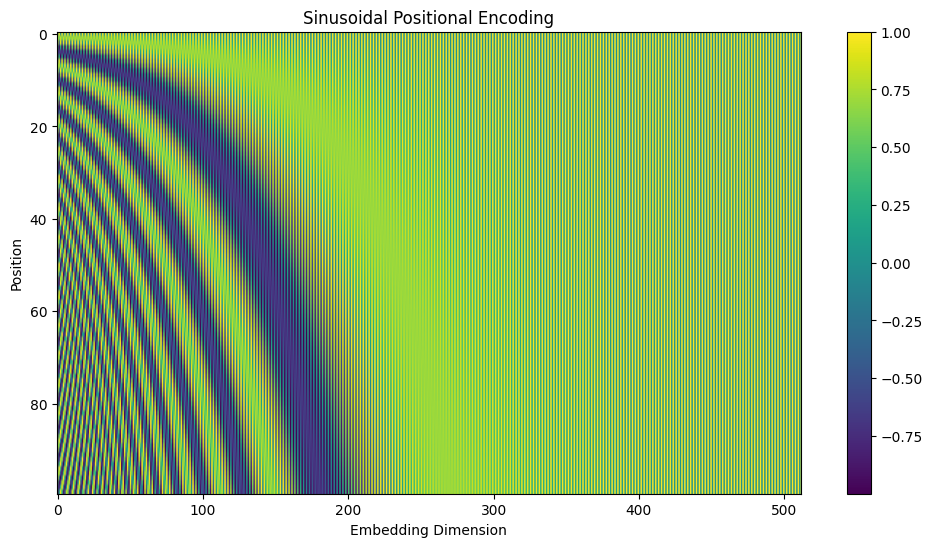

In [4]:
import matplotlib.pyplot as plt

PE = positional_encoding(
    seq_len=100,
    d_model=512
)

plt.figure(figsize=(12, 6))
plt.imshow(PE, aspect="auto")
plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.title("Sinusoidal Positional Encoding")
plt.colorbar()
plt.show()

**The plot shows how the values change across:**

```text
Position
    ↓
and
    →
Embedding Dimension
```

Different dimensions vary at different frequencies.

---

# 🎛️ **Different Frequencies**

One of the important ideas behind sinusoidal positional encoding is that different dimensions use different frequencies.

Conceptually:

```text
Dimension Pair 1
→ changes relatively quickly

Dimension Pair 2
→ changes more slowly

Dimension Pair 3
→ changes even more slowly

...
```

This gives every position a structured pattern across the dimensions.

Therefore, the positional vector contains information at multiple scales.

---

# 🧠 **Why Use Different Frequencies?**

Suppose every dimension used exactly the same sine wave.

Then the positional representation would contain limited information.

Instead, the Transformer uses many sine and cosine waves with different wavelengths.

**Conceptually:**

```text
Fast-changing dimensions
        ↓
Capture fine positional differences

Slow-changing dimensions
        ↓
Capture broader positional relationships
```

This creates a rich positional signature for every token position.

---

# 🔄 **Important Idea: Same Position, Different Dimensions**

For one position, different dimensions use different frequencies.

**For example:**

```text
Position 1

Dimension 0 → sin(frequency 1 × position)

Dimension 1 → cos(frequency 1 × position)

Dimension 2 → sin(frequency 2 × position)

Dimension 3 → cos(frequency 2 × position)

...
```

Therefore, one positional encoding vector is a combination of many sine/cosine signals.

---

# 🔄 **Important Idea: Different Positions**

For different positions, the same dimension follows the same sinusoidal function but at a different point along the wave.

**For example:**

```text
Position 1 → P₁

Position 2 → P₂

Position 3 → P₃

Position 4 → P₄
```

This creates a systematic relationship between position and encoding.

---

# ⚖️ **Learned vs Sinusoidal Positional Encoding**

| Feature | Learned Positional Encoding | Sinusoidal Positional Encoding |
|---|---|---|
| How values are created | Learned during training | Fixed mathematical formula |
| Trainable parameters | Yes | No |
| Extra parameter count | Yes | No |
| Maximum length | Usually tied to learned positional table | Can be computed for arbitrary positions |
| Original Transformer | No | Yes |
| Uses sin/cos | No | Yes |

---

# ❓ **Why Did the Original Transformer Use Sinusoidal Encoding?**

The original Transformer paper used sinusoidal positional encoding because it provides a deterministic representation of position without requiring a separate learned vector for every position.

The paper also noted that sinusoidal encodings may allow the model to extrapolate to sequence lengths longer than those seen during training.

However:

> **Extrapolation is not a guarantee of excellent performance on arbitrarily long sequences.**

The actual usable context length of a modern Transformer depends on its architecture, training, implementation, and model design.

---

# 🧠 **Positional Encoding vs Token Embedding**

It is important not to confuse these two.

## **Token Embedding**

**Answers:**

> **"What token is this?"**

**For example:**

```text
"We"
```

has an embedding that captures learned semantic information.

---

## **Positional Encoding**

**Answers:**

> **"Where is this token in the sequence?"**

**For example:**

```text
Position 1
Position 2
Position 3
Position 4
```

---

## **Together**

The Transformer receives:

```text
Token Meaning
      +
Token Position
      ↓
Final Input Representation
```

---

# 🔥 **Very Important Distinction**

**Consider:**

```text
"We are learning transformer"
```

**and:**

```text
"transformer learning are We"
```

The same token vocabulary may appear in both sentences, but the positions are different.

**Positional encoding helps the model distinguish:**

```text
Token Identity
+
Token Position
```

This is why position information is important in language.

---

# 🏗️ **Where Positional Encoding Appears in the Transformer**

**For the original Transformer Encoder:**

```text
Input Tokens

      ↓

Tokenization

      ↓

Input IDs

      ↓

Token Embedding

      ↓

Scale by √d_model

      ↓

Add Positional Encoding

      ↓

Encoder

      ↓

Multi-Head Self-Attention
```

The Decoder also receives target embeddings together with positional information.

**Conceptually:**

```text
Target Tokens

      ↓

Target Embedding

      ↓

Scale by √d_model

      ↓

Add Positional Encoding

      ↓

Masked Self-Attention
```

---

# 📌 **Original Transformer Values**

**The original Transformer used:**

```text
d_model = 512

Number of Encoder Layers = 6

Number of Decoder Layers = 6

Number of Attention Heads = 8

d_ff = 2048
```

**For positional encoding:**

```text
Embedding Dimension = 512

Positional Encoding Dimension = 512
```

and the positional encoding was:

```text
Sinusoidal
```

---

# 🔬 **One Full Example**

**Consider:**

```text
"We are learning transformer"
```

## **Step 1 — Tokenization**

```text
["We", "are", "learning", "transformer"]
```

---

## **Step 2 — Token IDs**

**Example:**

```text
[876, 10, 56, 213]
```

---

## **Step 3 — Token Embeddings**

```text
876 → W

10  → A

56  → L

213 → T
```

Each vector has:

```text
512 dimensions
```

---

## **Step 4 — Generate Positional Encodings**

```text
"We"          → P₁

"are"         → P₂

"learning"    → P₃

"transformer" → P₄
```

**Each positional vector has:**

```text
512 dimensions
```

---

## **Step 5 — Add Them**

```text
W + P₁

A + P₂

L + P₃

T + P₄
```

---

## **Step 6 — Pass to Encoder**

```text
Position-Aware Input

        ↓

Multi-Head Self-Attention

        ↓

Add & Norm

        ↓

Feed Forward

        ↓

Add & Norm
```

and this process repeats through the Encoder layers.

---

# 🧭 **Complete Positional Encoding Flow**

```text
Input Sentence

"We are learning transformer"

        ↓

Tokenization

        ↓

Token IDs

        ↓

Token Embedding

        ↓

Scale by √d_model
        |
        |
        +───────────────+
                        |
                        ↓
              Positional Encoding
                        |
                        ↓
                  Element-wise
                     Addition
                        |
                        ↓
             Position-Aware Input
                        |
                        ↓
                      Encoder
                        |
                        ↓
              Multi-Head Attention
```

---

# 🧮 **Quick Calculation**

**For:**

```text
pos = 1

i = 0

d_model = 512
```

**we have:**

$$
PE_{(1,0)}
=
\sin
\left(
\frac{1}
{10000^{\frac{2(0)}{512}}}
\right)
$$

**Therefore:**

$$
PE_{(1,0)}
=
\sin(1)
$$

**and:**

```text
PE(1,0) ≈ 0.84147
```

For the next dimension:

```text
PE(1,1) = cos(1) ≈ 0.54030
```

So the positional vector begins approximately as:

```text
P₁ = [0.84147, 0.54030, ...]
```

---

# ⚠️ **Common Mistakes**

## **Mistake 1 — Using the wrong exponent**

**The formula is:**

$$
10000^{\frac{2i}{d_{model}}}
$$

**not:**

```text
10000^(2 / d_model)
```

for every dimension.

The value of `i` changes from one dimension pair to another.

---

## **Mistake 2 — Forgetting the odd/even rule**

**Remember:**

```text
Even dimensions → sin

Odd dimensions  → cos
```

---

## **Mistake 3 — Confusing `i` with the actual dimension**

**The formulas use:**

```text
2i
```

**and:**

```text
2i+1
```

as the actual dimension indices.

**For example:**

```text
i = 0 → dimensions 0 and 1

i = 1 → dimensions 2 and 3

i = 2 → dimensions 4 and 5
```

---

## **Mistake 4 — Thinking positional encoding replaces embeddings**

It does not.

**The operation is:**

```text
Embedding + Positional Encoding
```

not:

```text
Embedding → Positional Encoding
```

as a replacement.

---

## **Mistake 5 — Assuming sinusoidal encoding automatically allows unlimited context**

The formula can be evaluated for larger positions, but that does **not** mean every trained Transformer will perform well on arbitrarily long sequences.

---

# 🔑 **Important Concepts to Remember**

```text
Language depends on token order.

        ↓

Self-Attention alone does not explicitly encode order.

        ↓

We add positional information.

        ↓

Token Embedding + Positional Encoding

        ↓

Position-Aware Representation
```

**For sinusoidal positional encoding:**

```text
Even dimensions → sin

Odd dimensions  → cos
```

**Formula:**

$$
PE_{(pos,2i)}
=
\sin
\left(
\frac{pos}
{10000^{\frac{2i}{d_{model}}}}
\right)
$$

$$
PE_{(pos,2i+1)}
=
\cos
\left(
\frac{pos}
{10000^{\frac{2i}{d_{model}}}}
\right)
$$

**For the original Transformer:**

```text
d_model = 512
```

**Therefore:**

```text
Position 1 → 512-dimensional vector

Position 2 → 512-dimensional vector

Position 3 → 512-dimensional vector

...

Position L → 512-dimensional vector
```

---

# 📌 **Summary**

- **Positional Encoding** provides information about the order of tokens.
- It is important because **Self-Attention does not inherently encode sequence order**.
- A positional vector is **added** to the corresponding token embedding.
- The positional encoding dimension must match **\(d_{model}\)**.
- The two common approaches are **Learned Positional Encoding** and **Sinusoidal Positional Encoding**.
- Learned positional encodings are trainable parameters.
- Learned positional tables are generally tied to the positional range for which they were created.
- Sinusoidal positional encoding uses **sine and cosine functions**.
- The original Transformer used **sinusoidal positional encoding**.
- **Even dimensions use sine**.
- **Odd dimensions use cosine**.
- In the original Transformer, **\(d_{model}=512\)**.
- The positional encoding therefore contains **512 values per position**.
- Different dimensions use different frequencies.
- Token embeddings contain information about the **token**.
- Positional encodings contain information about the **position**.
- Together they create a **position-aware representation**.
- The original Transformer scales token embeddings by **\(\sqrt{d_{model}}\)** before adding positional encodings.
- Sinusoidal encoding can be computed for positions beyond the original training range, but this does not guarantee good performance on arbitrarily long sequences.

---

# 🚀 **One-Line Memory Trick**

> **Embedding tells the Transformer "WHAT is the token", while Positional Encoding tells it "WHERE is the token".**
